# Fashion-MNIST con TensorFlow

En este notebook vamos a construir, entrenar y evaluar una red neuronal para clasificar prendas de vestir usando el dataset Fashion-MNIST. La idea es avanzar con calma: primero entenderemos los datos, luego prepararemos el modelo y al final revisaremos sus resultados con gráficas fáciles de interpretar.

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import confusion_matrix, classification_report

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Numpy:", np.__version__)

TensorFlow: 2.21.0
Numpy: 2.2.6


## 1. Entendamos el problema

Fashion-MNIST contiene imágenes en escala de grises de 28 x 28 píxeles y 10 categorías de prendas. Es un excelente punto de partida porque el problema es realista, pero sigue siendo lo bastante pequeño para que podamos concentrarnos en aprender el flujo completo de un proyecto de clasificación con redes neuronales.

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)
print("Primeras etiquetas:", y_train[:10])

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)
Primeras etiquetas: [9 0 0 3 0 2 7 2 5 5]


## 2. Exploración visual

Antes de entrenar, conviene mirar algunas imágenes para entender qué tan difíciles son las clases. También revisaremos cuántos ejemplos tiene cada categoría, porque eso nos ayuda a detectar posibles sesgos en el dataset.

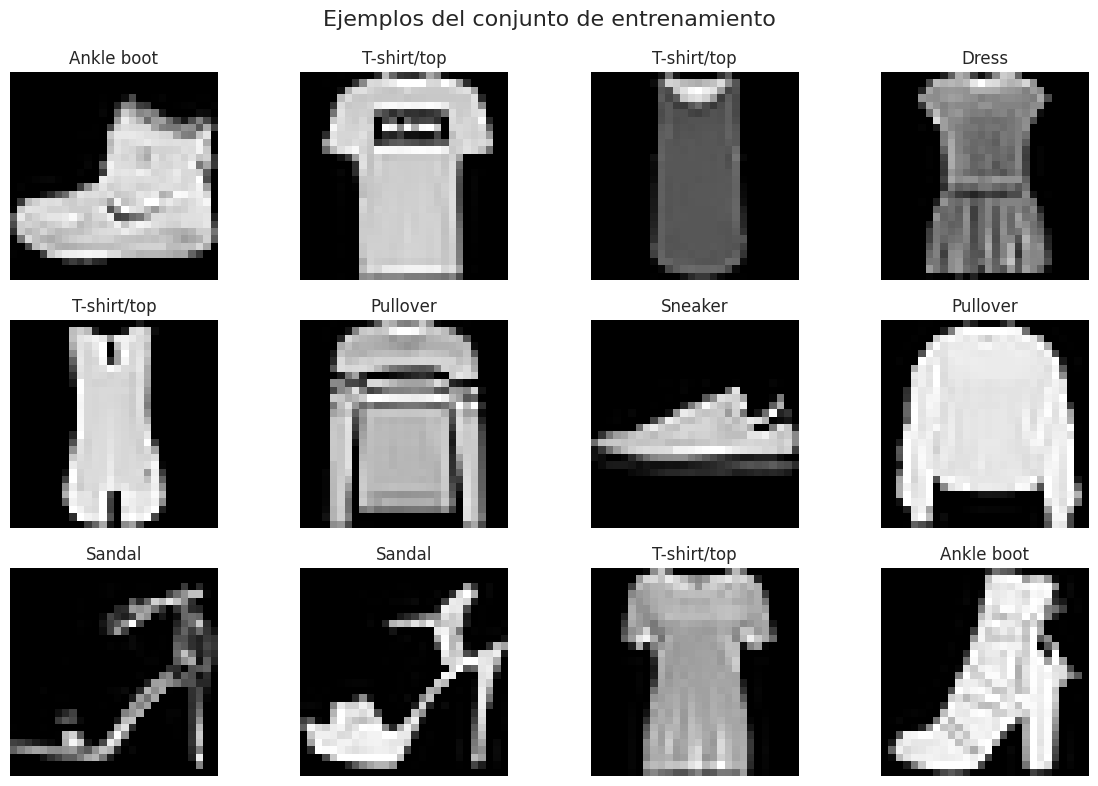

/tmp/ipykernel_10929/1191286828.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=counts, palette="viridis")


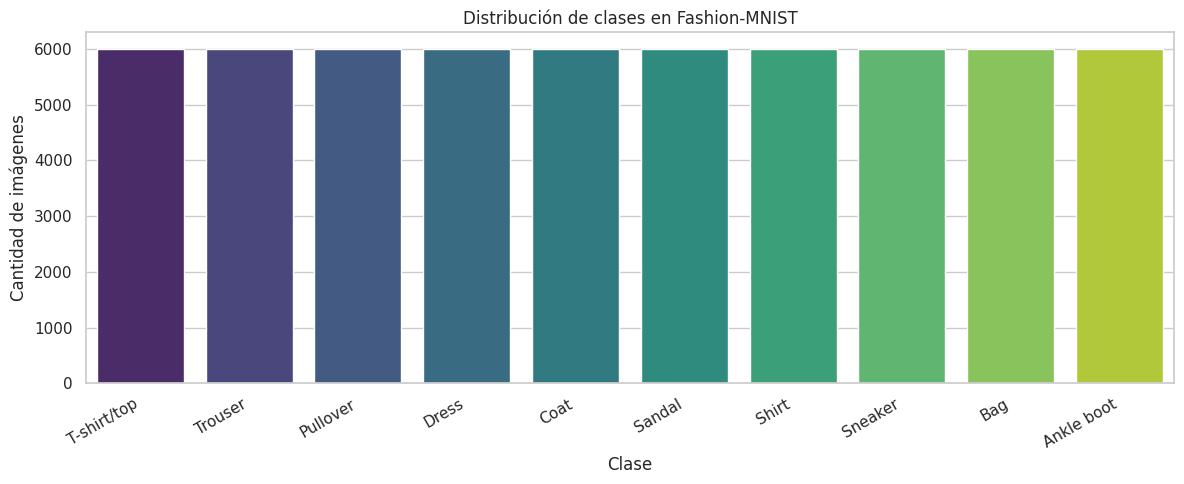

In [3]:
fig, axes = plt.subplots(3, 4, figsize=(12, 8))
axes = axes.ravel()

for i in range(12):
    axes[i].imshow(x_train[i], cmap="gray")
    axes[i].set_title(class_names[y_train[i]])
    axes[i].axis("off")

plt.suptitle("Ejemplos del conjunto de entrenamiento", fontsize=16)
plt.tight_layout()
plt.show()

counts = np.bincount(y_train)
plt.figure(figsize=(12, 5))
sns.barplot(x=class_names, y=counts, palette="viridis")
plt.title("Distribución de clases en Fashion-MNIST")
plt.xlabel("Clase")
plt.ylabel("Cantidad de imágenes")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 3. Preparación de los datos

Las imágenes vienen como arreglos de 28 x 28 píxeles. Para que la red neuronal trabaje mejor, normalizamos los valores entre 0 y 1 y agregamos una dimensión extra para que TensorFlow las interprete como imágenes en escala de grises con un canal.

In [4]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("x_train preprocesado:", x_train.shape)
print("x_test preprocesado:", x_test.shape)
print("Rango de valores:", x_train.min(), "a", x_train.max())

x_train preprocesado: (60000, 28, 28, 1)
x_test preprocesado: (10000, 28, 28, 1)
Rango de valores: 0.0 a 1.0


## 4. Construcción del modelo

Vamos a usar una red convolucional sencilla. La idea es que las capas convolucionales aprendan patrones visuales como bordes y formas, y que las capas densas finales conviertan esa información en una predicción para cada una de las 10 clases.

In [5]:
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(10, activation="softmax"),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Entrenamiento

Ahora compilamos el modelo y lo entrenamos. Usaremos `Adam`, porque suele funcionar muy bien como punto de partida, y `early stopping` para evitar que el modelo siga aprendiendo cuando ya no mejora en validación.

In [6]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

history = model.fit(
    x_train,
    y_train,
    epochs=12,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1,
)

W0000 00:00:1779379940.830305   10929 cpu_allocator_impl.cc:82] Allocation of 150528000 exceeds 10% of free system memory.


Epoch 1/12
749/750 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6604 - loss: 0.9270

W0000 00:00:1779379976.389256   10929 cpu_allocator_impl.cc:82] Allocation of 37632000 exceeds 10% of free system memory.


750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.7584 - loss: 0.6576 - val_accuracy: 0.8544 - val_loss: 0.4168
Epoch 2/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 30s 40ms/step - accuracy: 0.8404 - loss: 0.4377 - val_accuracy: 0.8707 - val_loss: 0.3549
Epoch 3/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 33s 43ms/step - accuracy: 0.8625 - loss: 0.3822 - val_accuracy: 0.8859 - val_loss: 0.3105
Epoch 4/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 30s 41ms/step - accuracy: 0.8736 - loss: 0.3474 - val_accuracy: 0.8907 - val_loss: 0.2918
Epoch 5/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 46s 47ms/step - accuracy: 0.8793 - loss: 0.3302 - val_accuracy: 0.8915 - val_loss: 0.2833
Epoch 6/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 33s 44ms/step - accuracy: 0.8855 - loss: 0.3124 - val_accuracy: 0.9019 - val_loss: 0.2653
Epoch 7/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 33s 43ms/step - accuracy: 0.8915 - loss: 0.2986 - val_accuracy: 0.9031 - val_loss: 0.2633
Epoch 8/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 45ms/step - accuracy: 0.8952 - loss: 0.2879 - val_accurac

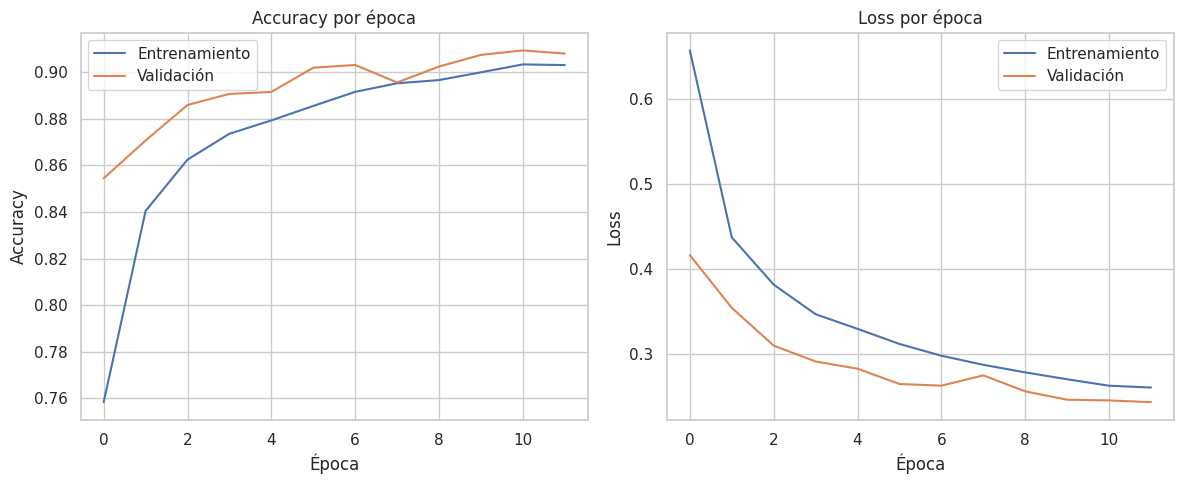

In [7]:
history_dict = history.history

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_dict["accuracy"], label="Entrenamiento")
plt.plot(history_dict["val_accuracy"], label="Validación")
plt.title("Accuracy por época")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_dict["loss"], label="Entrenamiento")
plt.plot(history_dict["val_loss"], label="Validación")
plt.title("Loss por época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## 6. Evaluación final

Con el modelo ya entrenado, medimos su desempeño en el conjunto de prueba, revisamos la matriz de confusión y observamos algunas predicciones. Así vemos no solo cuánto acierta, sino también en qué clases se confunde más.

W0000 00:00:1779380361.780211   10929 cpu_allocator_impl.cc:82] Allocation of 31360000 exceeds 10% of free system memory.


Pérdida en test: 0.2571
Accuracy en test: 0.9051


W0000 00:00:1779380364.745234   10929 cpu_allocator_impl.cc:82] Allocation of 31360000 exceeds 10% of free system memory.


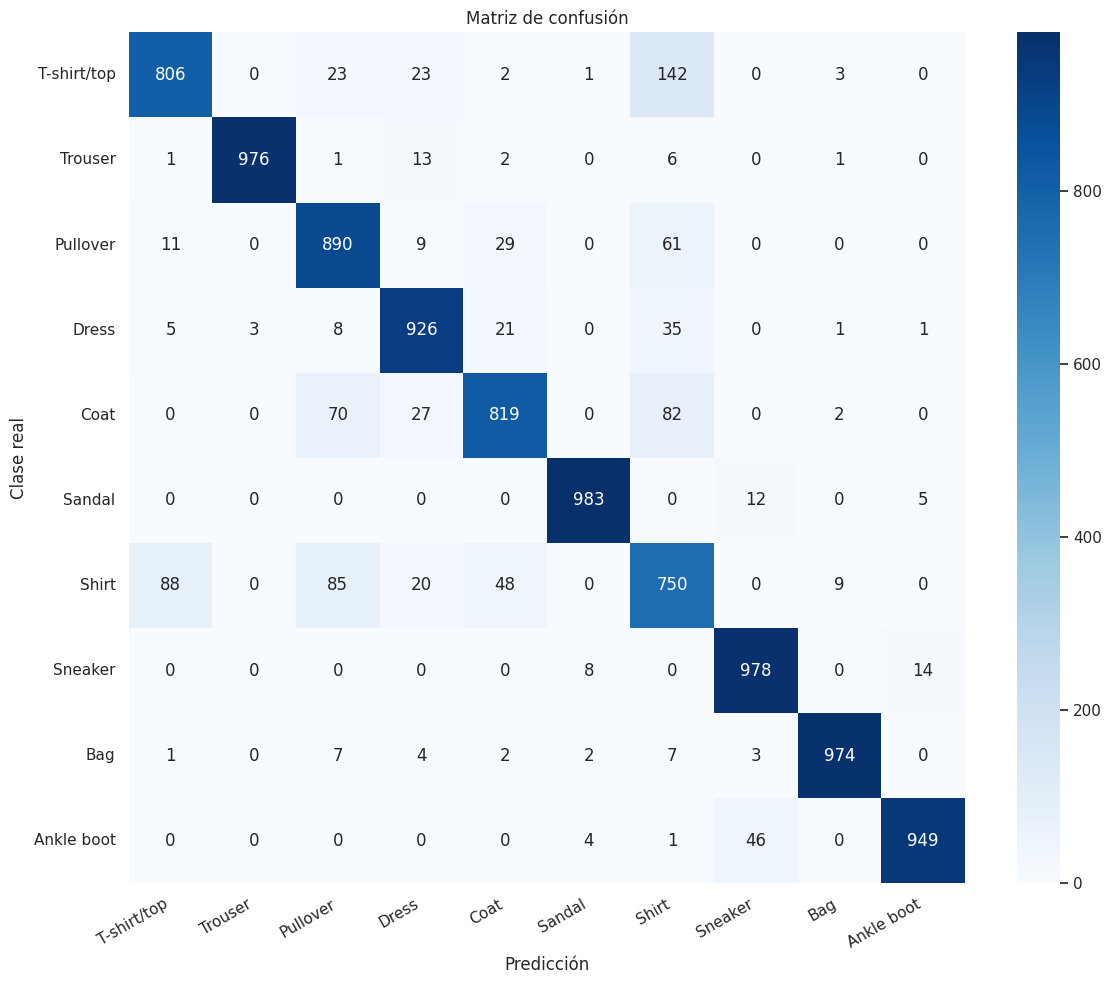

              precision    recall  f1-score   support

 T-shirt/top       0.88      0.81      0.84      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.82      0.89      0.85      1000
       Dress       0.91      0.93      0.92      1000
        Coat       0.89      0.82      0.85      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.69      0.75      0.72      1000
     Sneaker       0.94      0.98      0.96      1000
         Bag       0.98      0.97      0.98      1000
  Ankle boot       0.98      0.95      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [8]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Pérdida en test: {test_loss:.4f}")
print(f"Accuracy en test: {test_accuracy:.4f}")

pred_probs = model.predict(x_test, verbose=0)
y_pred = np.argmax(pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Clase real")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=class_names))

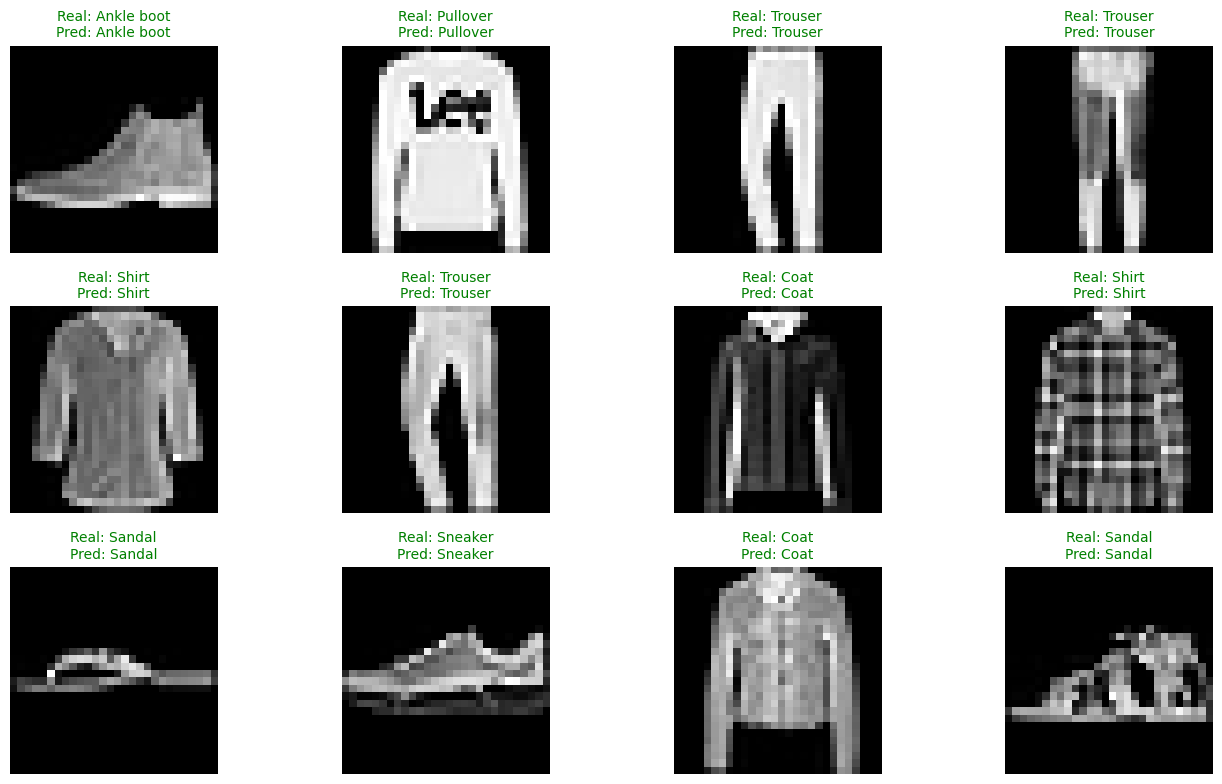

In [9]:
def mostrar_predicciones(imagenes, etiquetas_reales, etiquetas_predichas, class_names, n=12):
    plt.figure(figsize=(14, 8))
    for i in range(n):
        plt.subplot(3, 4, i + 1)
        plt.imshow(imagenes[i].squeeze(), cmap="gray")
        color = "green" if etiquetas_reales[i] == etiquetas_predichas[i] else "red"
        plt.title(
            f"Real: {class_names[etiquetas_reales[i]]}\nPred: {class_names[etiquetas_predichas[i]]}",
            color=color,
            fontsize=10,
        )
        plt.axis("off")
    plt.tight_layout()
    plt.show()

mostrar_predicciones(x_test, y_test, y_pred, class_names)

## 7. Conclusiones

En este proyecto vimos el flujo completo de una clasificación con TensorFlow: descargar datos, explorarlos, prepararlos, construir una red neuronal, entrenarla y analizar sus errores. Fashion-MNIST es un ejemplo excelente para aprender porque tiene suficiente complejidad para ser interesante, pero sigue siendo manejable para una primera aproximación.